<a href="https://colab.research.google.com/github/abhi2005-bit/Deep-Learning/blob/main/Neural_network__classificationynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
 import sklearn

In [115]:
#Neural network classification with pytorch
#1.make some data
from sklearn.datasets import make_circles

#make 1000 samples
n_samples = 1000

#create circles
x,y=make_circles(n_samples,
                 noise = 0.03,
                 random_state = 42)
len(x),len(y)

(1000, 1000)

In [116]:
print(f"first five samples of x :{x[:5]}")
print(f"first five samples of y:{y[:5]}")

first five samples of x :[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first five samples of y:[1 1 1 1 0]


In [117]:
#make a data frame of circle data
import pandas as pd
circle = pd.DataFrame({"x1":x[:,0],
                       "x2":x[:,1],
                       "label":y
})
circle.head(10)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


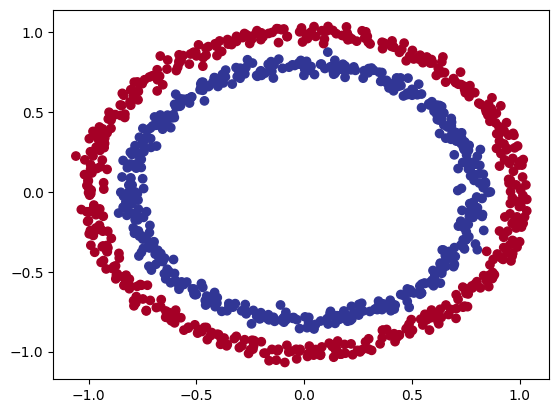

In [118]:
#visulaize
import matplotlib.pyplot as plt
plt.scatter(x=x[:,0]
            ,y=x[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);

In [119]:
#check input and output shapes
x.shape,y.shape

((1000, 2), (1000,))

In [120]:
x # has its x and y coordinates

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [121]:
#view the first examples of features and labels
x_sample=x[0]
y_sample=y[0]
print(f"value of one sample of x : {x_sample} and sahape {x_sample.shape}")
print(f"value of one sample of y : {y_sample} and shape {y_sample.shape}")

value of one sample of x : [0.75424625 0.23148074] and sahape (2,)
value of one sample of y : 1 and shape ()


In [122]:
#Turns data into tensors and create train and test splits
#turn data into tensors
import torch


In [123]:
x[:5], y[:5]
type(x)
type(y)

numpy.ndarray

In [124]:
#spliting data into trainig and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size = 0.2,#20 % of the data wil be test data
                                               random_state=42)


In [125]:
len(x_train),len(x_test),len(y_train),len(y_test)


(800, 200, 800, 200)

In [126]:
x_train = torch.from_numpy(x_train).float()
x_test  = torch.from_numpy(x_test).float()
y_train = torch.from_numpy(y_train).float()
y_test  = torch.from_numpy(y_test).float()

In [127]:
# #building a model
# #lets build a model to classify our blue and red dot
# #to doso we want to:
# 1.setup device agnostic code so our code will run on accelerator(GPU)if there is one
# 2.construct a model
# 3.define a loss funcction and optimizer
# 4.create a training and test loop

In [128]:
#import pytorch and nn
import torch
from torch import nn

#make device agnostic code:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [129]:
#create our model
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #create 2 nn.Linear layers capable of handling the shape of our data
    #nn.linerar works on linear regression formula
    self.layer_1=nn.Linear(in_features=2,out_features=5)#take in 2 features and upscales to 5 features
    self.layer_2=nn.Linear(in_features=5,out_features=1)#takes in 5 features from previous layer and outputs single feature (same shape as y)
  #define a forward () meathod that outlines the forward pass
  def forward(self,x):
    return self.layer_2(self.layer_1(x))#x -> layer 1 -> layer 2
#istantiate a instance of our model class and send it to the target device
model_0=CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [130]:
device

'cuda'

In [131]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.3041, -0.0775],
                      [-0.5293,  0.6441],
                      [-0.5190,  0.3779],
                      [ 0.2485,  0.2298],
                      [-0.3823,  0.6427]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.1554,  0.0910, -0.6231,  0.2968, -0.1061], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2049,  0.3841,  0.0997, -0.2474, -0.2264]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.0214], device='cuda:0'))])

In [132]:
with torch.inference_mode():
  untrained_preds=model_0(x_test.to(device))
  print(f"length of predictions : {len(untrained_preds)}")
  print(f"shape of predictions : {untrained_preds.shape}")
  print(f"Length of test samples : {len(y_test)}")
  print(f"Shape of test samples : {x_test.shape}")
  print(f"\n first 10 predicctions :\n {torch.round(untrained_preds[:10])}")
  print(f"\n first 10 labels :\n {y_test[:10]} ")

length of predictions : 200
shape of predictions : torch.Size([200, 1])
Length of test samples : 200
Shape of test samples : torch.Size([200, 2])

 first 10 predicctions :
 tensor([[0.],
        [-0.],
        [-0.],
        [0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]], device='cuda:0')

 first 10 labels :
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]) 


In [133]:
#loss functions(BCE):
loss_fn = nn.BCEWithLogitsLoss()#sigmoid activation function built in

#optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.1)
# calculate accuracy
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [134]:
#Training the model
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(x_test.to(device))[:5]
y_logits

tensor([[ 0.0004],
        [-0.0377],
        [-0.0430],
        [ 0.0133],
        [-0.2707]], device='cuda:0')

In [135]:
#logits are the raw output produced by our model
#we can convert logits into prediction probabilities by passinngit
#activation function(sigmoid or softmax)

In [136]:
#use sigmoid activation function
y_preds_probe=torch.sigmoid(y_logits)
y_preds_probe

tensor([[0.5001],
        [0.4906],
        [0.4893],
        [0.5033],
        [0.4327]], device='cuda:0')

In [137]:
y_preds=torch.round(y_preds_probe)
y_pred_labels=torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 0., 0., 1., 0.], device='cuda:0')

In [138]:
!nvidia-smi

Mon Jul  6 17:30:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             27W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [139]:
torch.manual_seed(42)

#set the number of epochs
epochs = 100

#put the data to the target device
x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  #forward pass
  y_logits = model_0(x_train.to(device)).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))#turn logits to pred probs and then pred labels

  #calculate loss
  loss = loss_fn(y_logits,y_train)#BCE expects raw logits as input
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_preds)

  #loss backward
  loss.backward()

  #optimizer zero grad
  optimizer.step()

  ##testing
  model_0.eval()
  with torch.inference_mode():
    #1.forward pass
    test_logits = model_0(x_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)
  #print
  if epoch % 10 == 0:
    print(f"epoch {epoch} | loss : {loss :.5f} | acc : {acc :.2f}% | test_loss : {test_loss :.5f}, test_acc : {test_acc :.2f}%")

epoch 0 | loss : 0.69713 | acc : 46.75% | test_loss : 0.69687, test_acc : 43.50%
epoch 10 | loss : 0.69453 | acc : 50.00% | test_loss : 0.69456, test_acc : 50.00%
epoch 20 | loss : 0.69380 | acc : 50.50% | test_loss : 0.69378, test_acc : 49.00%
epoch 30 | loss : 0.69594 | acc : 50.00% | test_loss : 0.69836, test_acc : 50.00%
epoch 40 | loss : 0.69501 | acc : 55.00% | test_loss : 0.70116, test_acc : 56.00%
epoch 50 | loss : 0.69406 | acc : 52.88% | test_loss : 0.69839, test_acc : 47.00%
epoch 60 | loss : 0.69571 | acc : 50.00% | test_loss : 0.69780, test_acc : 50.00%
epoch 70 | loss : 0.69352 | acc : 50.25% | test_loss : 0.69376, test_acc : 53.50%
epoch 80 | loss : 0.69534 | acc : 50.00% | test_loss : 0.69472, test_acc : 50.00%
epoch 90 | loss : 0.69379 | acc : 48.50% | test_loss : 0.69473, test_acc : 44.50%


In [140]:
### Make predictions and evaluate the model
# From the matrics it loo like model is not learning anything
# So lets inspect it using predictions and make them visuals
import numpy as np
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


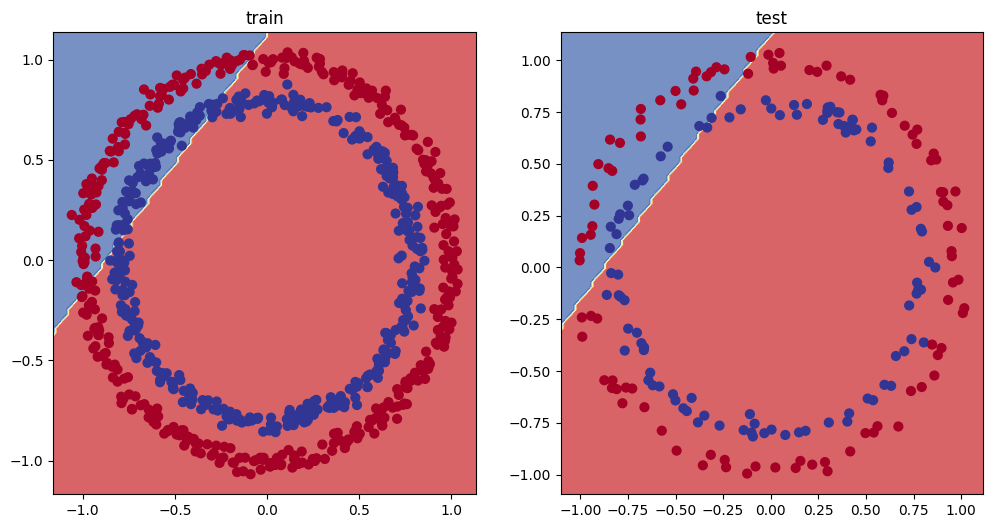

In [141]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_0,x_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_0,x_test,y_test)

In [142]:
##Improving our model
#1.add more layers
#2.add more hidden units
#3.Fit for longer
#4.Changing the activation function
#5.Changing the learning rate
#6.Change the Learning rate
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.2241, -0.0160],
                      [-0.3706,  0.5616],
                      [-0.3866,  0.3153],
                      [ 0.0765,  0.1171],
                      [-0.4017,  0.4788]])),
             ('layer_1.bias',
              tensor([ 0.0310,  0.0431, -0.1522,  0.0855, -0.0112])),
             ('layer_2.weight',
              tensor([[ 0.1120, -0.0251,  0.1063,  0.0112,  0.1495]])),
             ('layer_2.bias', tensor([-0.0872]))])

In [143]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    #lets try and imporve our model by:
    #1.adding more hidden units : 5-> 10
    #2.increase the number of layers : 2->3
    #3.increase the number of epochs
    self.layer_1=nn.Linear(in_features = 2,out_features=10)
    self.layer_2=nn.Linear(in_features = 10,out_features= 10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
  def forward(self,x):
    # z= self.layer_1(x)
    # z= self.layer_2(z)
    # z= self.layer_3(z)
    # return z
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1=CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [144]:
#create a loss function
loss_fn = nn.BCEWithLogitsLoss()
#create  an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [145]:
epochs = 1000
x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)

for epoch in range(epochs):
  #training
  model_1.train()
  y_logits=model_1(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits.to(device)))
  loss=loss_fn(y_logits,y_train)
  acc= accuracy_fn(y_true = y_train,
                   y_pred = y_pred)
  optimizer.zero_grad()
  loss.backward()

  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits,y_test)
    test_accuracy=accuracy_fn(y_true=y_test,
                              y_pred=test_pred)
    if epoch % 100 == 0:
      print(f"epoch : {epoch} | loss : {loss :.5f} | acc : {acc :.2f}% | test_loss : {test_loss :.5f}, test_acc : {test_accuracy :.2f}%")


epoch : 0 | loss : 0.69396 | acc : 50.88% | test_loss : 0.69261, test_acc : 51.00%
epoch : 100 | loss : 0.69305 | acc : 50.38% | test_loss : 0.69379, test_acc : 48.00%
epoch : 200 | loss : 0.69299 | acc : 51.12% | test_loss : 0.69437, test_acc : 46.00%
epoch : 300 | loss : 0.69298 | acc : 51.62% | test_loss : 0.69458, test_acc : 45.00%
epoch : 400 | loss : 0.69298 | acc : 51.12% | test_loss : 0.69465, test_acc : 46.00%
epoch : 500 | loss : 0.69298 | acc : 51.00% | test_loss : 0.69467, test_acc : 46.00%
epoch : 600 | loss : 0.69298 | acc : 51.00% | test_loss : 0.69468, test_acc : 46.00%
epoch : 700 | loss : 0.69298 | acc : 51.00% | test_loss : 0.69468, test_acc : 46.00%
epoch : 800 | loss : 0.69298 | acc : 51.00% | test_loss : 0.69468, test_acc : 46.00%
epoch : 900 | loss : 0.69298 | acc : 51.00% | test_loss : 0.69468, test_acc : 46.00%


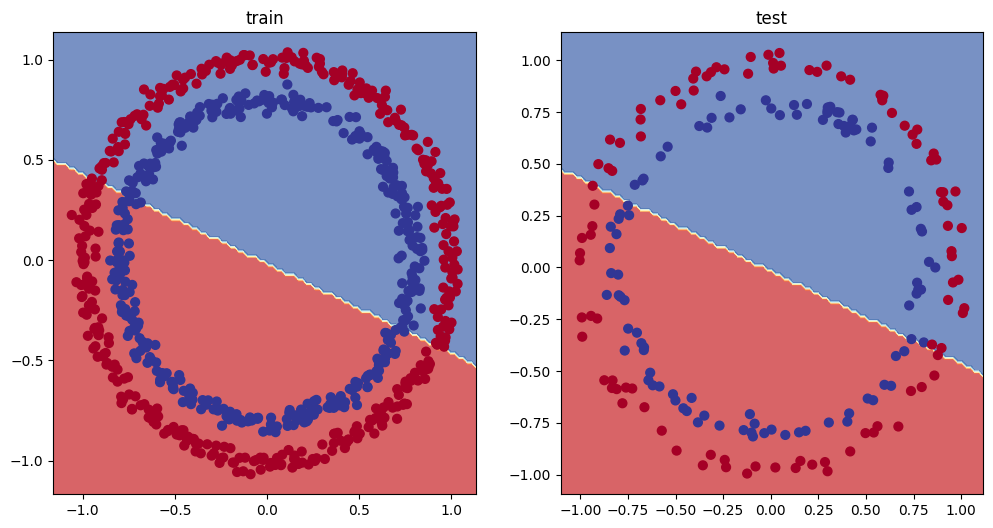

In [146]:
#plot the decison boundry
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_1,x_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_1,x_test,y_test)

In [147]:
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

In [148]:
## Preparinf data to see if our model can fit a straight line
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

x_regression = torch.arange(start,end,step)
y_regression = weight * x_regression + bias
x_regression[:5],y_regression[:5]

(tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400]),
 tensor([0.3000, 0.3070, 0.3140, 0.3210, 0.3280]))

In [149]:
train_split=int(0.8 * len(x_regression))
x_train_reg=x_regression[:train_split]
y_train_reg=y_regression[:train_split]
x_test_reg=x_regression[train_split:]
y_test_reg=y_regression[train_split:]

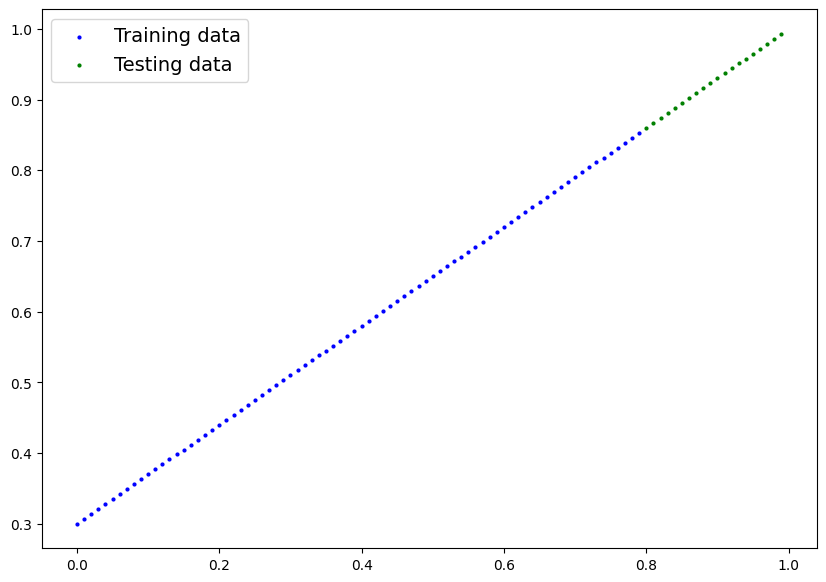

In [150]:
plot_predictions(train_data=x_train_reg,
                 train_labels=y_train_reg,
                 test_data=x_test_reg,
                 test_labels=y_test_reg);

In [151]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [152]:
##Adjust the model_1 to fit a straight line
#Same architecture as model_1 but only in feature = 1
model_2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [153]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.01)


In [154]:
import torch
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=1000

x_train_reg,y_train_reg=x_train_reg.unsqueeze(1).to(device),y_train_reg.to(device)
x_test_reg,y_test_reg=x_test_reg.unsqueeze(1).to(device),y_test_reg.to(device)

In [155]:
for epoch in range(epochs):
  model_2.train()
  y_preds=model_2(x_train_reg).squeeze()
  loss=loss_fn(y_preds,y_train_reg)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_preds=model_2(x_test_reg).squeeze()
    test_loss=loss_fn(test_preds,y_test_reg)

    if epoch % 100 == 0:
      print(f"epoch : {epoch} | loss : {loss :.5f} | test_loss : {test_loss :.5f}")

epoch : 0 | loss : 0.75986 | test_loss : 0.91103
epoch : 100 | loss : 0.02858 | test_loss : 0.00081
epoch : 200 | loss : 0.02533 | test_loss : 0.00209
epoch : 300 | loss : 0.02137 | test_loss : 0.00305
epoch : 400 | loss : 0.01964 | test_loss : 0.00341
epoch : 500 | loss : 0.01940 | test_loss : 0.00387
epoch : 600 | loss : 0.01903 | test_loss : 0.00379
epoch : 700 | loss : 0.01878 | test_loss : 0.00381
epoch : 800 | loss : 0.01840 | test_loss : 0.00329
epoch : 900 | loss : 0.01798 | test_loss : 0.00360


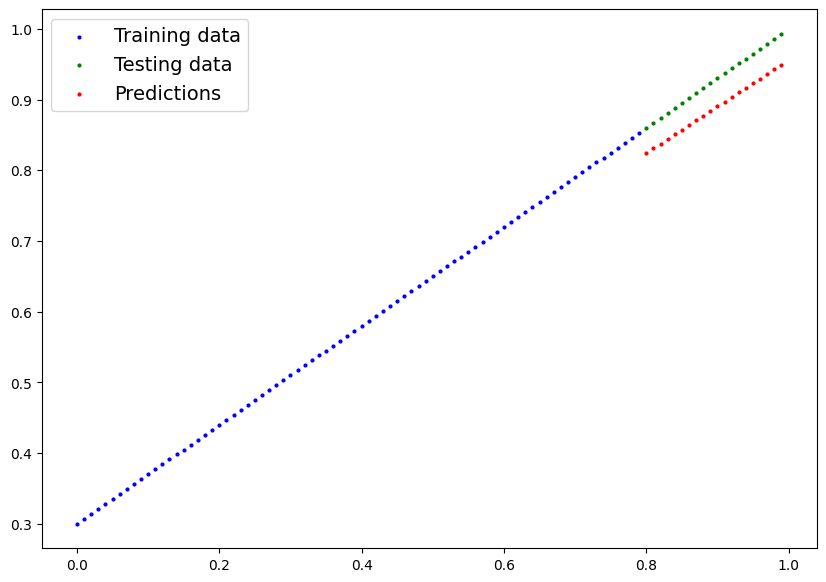

In [156]:
plot_predictions(train_data=x_train_reg.cpu(), train_labels=y_train_reg.cpu(), test_data=x_test_reg.cpu(), test_labels=y_test_reg.cpu(), predictions=test_preds.cpu())

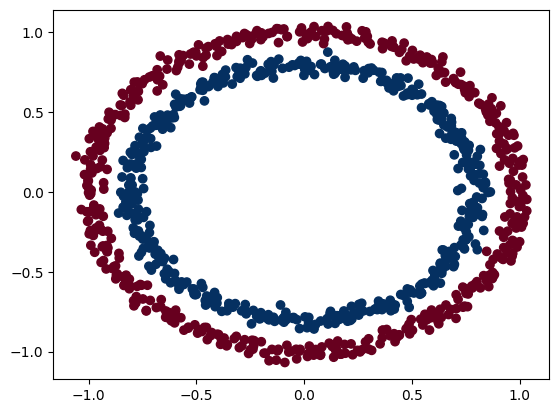

In [157]:
#we neend to add non linerity in our classification to classofy the circle
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples= 1000
x,y=make_circles(n_samples,
                 noise = 0.03,
                 random_state = 42)
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdBu);

In [158]:
# convert data to tensors
import torch
from sklearn.model_selection import train_test_split
x= torch.from_numpy(x).type(torch.float)
y= torch.from_numpy(y).type(torch.float)
x_train,x_test,y_train,y_test=train_test_split(x,
                                              y,
                                              test_size = 0.2,
                                              random_state=42)

In [159]:
#Building a model with non-linearity
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()#non linear activation function

  def forward(self,x):

    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [160]:
#Artificial Neural Network are a large combination of linear and non linear functions which are potentially able to find the pattern in the data

In [161]:
model_3=CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [162]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model_3.parameters(),
                          lr = 0.1)


In [166]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)
epochs = 1000
for epoch in range(epochs):
  # Training
  model_3.train() # Make sure model is in training mode
  y_logits=model_3(x_train).squeeze()
  y_preds= torch.round(torch.sigmoid(y_logits)) # Fix: use y_logits here
  loss=loss_fn(y_logits,y_train) # Fix: BCEWithLogitsLoss expects logits, not rounded predictions
  acc=accuracy_fn(y_true= y_train,
                  y_pred=y_preds)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits=model_3(x_test).squeeze()
    test_preds=torch.round(torch.sigmoid(test_logits)) # Fix: sigmod to sigmoid
    test_loss=loss_fn(test_logits,y_test) # Fix: BCEWithLogitsLoss expects logits
    test_accuracy=accuracy_fn(y_true=y_test,
                              y_pred=test_preds)

    if epoch % 100 == 0: # Fix: epochs to epoch, and add == 0
      print(f"epoch : {epoch} | loss : {loss :.4f} | acc : {acc :.2f}% | test_loss : {test_loss :.5f}, test_acc : {test_accuracy :.2f}%")

epoch : 0 | loss : 0.6929 | acc : 50.00% | test_loss : 0.69319, test_acc : 50.00%
epoch : 100 | loss : 0.6912 | acc : 52.88% | test_loss : 0.69102, test_acc : 52.50%
epoch : 200 | loss : 0.6898 | acc : 53.37% | test_loss : 0.68940, test_acc : 55.00%
epoch : 300 | loss : 0.6879 | acc : 53.00% | test_loss : 0.68723, test_acc : 56.00%
epoch : 400 | loss : 0.6852 | acc : 52.75% | test_loss : 0.68411, test_acc : 56.50%
epoch : 500 | loss : 0.6810 | acc : 52.75% | test_loss : 0.67941, test_acc : 56.50%
epoch : 600 | loss : 0.6751 | acc : 54.50% | test_loss : 0.67285, test_acc : 56.00%
epoch : 700 | loss : 0.6666 | acc : 58.38% | test_loss : 0.66322, test_acc : 59.00%
epoch : 800 | loss : 0.6516 | acc : 64.00% | test_loss : 0.64757, test_acc : 67.50%
epoch : 900 | loss : 0.6236 | acc : 74.00% | test_loss : 0.62145, test_acc : 79.00%
